# 03 - Analise exploratoria dos dados

Este notebook aprofunda a analise exploratoria dos microdados de acidentes da PRF, com recorte principal em **Santa Catarina (UF = SC)** e foco no problema do projeto: **predicao temporal da quantidade de acidentes em rodovias federais catarinenses**.

A EDA esta organizada para responder quatro perguntas praticas:

1. Qual e o volume, cobertura temporal e qualidade da base disponivel?
2. Quais padroes temporais, sazonais e horarios aparecem nos acidentes de SC?
3. Quais rodovias, municipios, trechos, causas e condicoes concentram maior volume e maior severidade?
4. Quais agregacoes e variaveis parecem mais uteis para a etapa de modelagem temporal?

> Observacao: os arquivos da pasta `data/raw` estao em CSV separado por `;` e codificados em `latin-1`. O notebook trata isso explicitamente para preservar acentos nos textos.

## 1. Preparacao do ambiente

As bibliotecas abaixo cobrem manipulacao de dados, visualizacao e tabelas analiticas. Caso alguma importacao falhe, instale as dependencias do projeto com:

```bash
uv pip install -r requirements.txt
```

ou, em ambientes sem `uv`:

```bash
pip install -r requirements.txt
```

In [1]:
from pathlib import Path
import warnings

try:
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    from IPython.display import display, Markdown
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Dependencia ausente. Instale com: uv pip install -r requirements.txt"
    ) from exc

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid", context="notebook")
PALETTE = ["#264653", "#2a9d8f", "#e9c46a", "#f4a261", "#e76f51", "#6d597a"]
sns.set_palette(PALETTE)

In [2]:
# Resolve caminhos tanto quando o notebook roda a partir da raiz quanto da pasta notebooks.
PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "raw").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

csv_files = sorted(RAW_DIR.glob("datatran*.csv"))
print(f"Raiz do projeto: {PROJECT_ROOT}")
print(f"Arquivos encontrados: {len(csv_files)}")
for file in csv_files:
    print("-", file.name)

Raiz do projeto: /Users/robertdrey/Documents/workspace/development/pgp_machine_learning
Arquivos encontrados: 6
- datatran2021.csv
- datatran2022.csv
- datatran2023.csv
- datatran2024.csv
- datatran2025.csv
- datatran2026.csv


## 2. Leitura, padronizacao e enriquecimento inicial

A leitura usa `dtype=str` para evitar conversoes prematuras. Depois disso, as colunas numericas, datas, coordenadas e variaveis temporais sao convertidas de forma controlada.

In [3]:
def read_prf_csv(path: Path) -> pd.DataFrame:
    # Le CSV anual da PRF preservando acentos e tipos originais.
    df_year = pd.read_csv(
        path,
        sep=";",
        encoding="latin-1",
        dtype=str,
        low_memory=False,
    )
    df_year["ano_arquivo"] = path.stem.replace("datatran", "")
    return df_year

if not csv_files:
    raise FileNotFoundError(f"Nenhum arquivo datatran*.csv encontrado em {RAW_DIR}")

df_raw = pd.concat([read_prf_csv(path) for path in csv_files], ignore_index=True)
print(f"Base bruta consolidada: {df_raw.shape[0]:,} linhas x {df_raw.shape[1]:,} colunas")
display(df_raw.head(3))

Base bruta consolidada: 372,398 linhas x 31 colunas


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano_arquivo
0,331730,2021-01-01,sexta-feira,05:30:00,SP,116,453,REGISTRO,Reação tardia ou ineficiente do condutor,Tombamento,Com Vítimas Feridas,Amanhecer,Crescente,Nublado,Dupla,Curva,Não,1,0,1,0,0,0,1,1,"-24,56168114","-47,86752174",SPRF-SP,DEL05-SP,UOP01-DEL05-SP,2021
1,331804,2021-01-01,sexta-feira,08:05:00,AM,174,937,MANAUS,Reação tardia ou ineficiente do condutor,Colisão traseira,NaN,Pleno dia,Crescente,Céu Claro,Simples,Reta,Não,7,0,1,0,5,1,1,5,"-2,508068","-60,036434",SPRF-AM,DEL01-AM,UOP01-DEL01-AM,2021
2,331815,2021-01-01,sexta-feira,10:10:00,CE,222,"128,5",ITAPAJE,Velocidade Incompatível,Tombamento,Com Vítimas Feridas,Pleno dia,Crescente,Céu Claro,Simples,Curva,Não,3,0,2,0,0,11,2,12,"-3,707626","-39,623509",SPRF-CE,DEL04-CE,UOP03-DEL04-CE,2021


In [4]:
df = df_raw.copy()

# Limpeza leve de textos: remove espacos nas bordas e transforma strings vazias em nulos.
for col in df.select_dtypes(include="object").columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace({"": np.nan})

# Datas aparecem em dois formatos na base local: yyyy-mm-dd e dd/mm/yyyy.
# A conversao em duas passagens evita ambiguidades como 2021-01-02 virar 2021-02-01.
date_text = df["data_inversa"].astype("string")
df["data"] = pd.to_datetime(date_text, format="%Y-%m-%d", errors="coerce")
missing_date = df["data"].isna()
df.loc[missing_date, "data"] = pd.to_datetime(date_text[missing_date], format="%d/%m/%Y", errors="coerce")
df["ano"] = df["data"].dt.year.astype("Int64")

df["hora"] = pd.to_numeric(df["horario"].str.slice(0, 2), errors="coerce").astype("Int64")
df["minuto"] = pd.to_numeric(df["horario"].str.slice(3, 5), errors="coerce").astype("Int64")

int_cols = ["pessoas", "mortos", "feridos_leves", "feridos_graves", "feridos", "ilesos", "ignorados", "veiculos"]
for col in int_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

for col in ["km", "latitude", "longitude"]:
    df[f"{col}_num"] = pd.to_numeric(df[col].str.replace(",", ".", regex=False), errors="coerce")

# Recorte principal do projeto.
df_sc = df[df["uf"].eq("SC")].copy()

# Variaveis temporais e indicadores de severidade.
dias_ordem = ["segunda-feira", "terça-feira", "quarta-feira", "quinta-feira", "sexta-feira", "sábado", "domingo"]
meses_nome = {
    1: "jan", 2: "fev", 3: "mar", 4: "abr", 5: "mai", 6: "jun",
    7: "jul", 8: "ago", 9: "set", 10: "out", 11: "nov", 12: "dez",
}

df_sc["mes"] = df_sc["data"].dt.month
df_sc["mes_nome"] = df_sc["mes"].map(meses_nome)
df_sc["trimestre"] = df_sc["data"].dt.quarter
df_sc["semana_iso"] = df_sc["data"].dt.isocalendar().week.astype("Int64")
df_sc["ano_semana"] = df_sc["data"].dt.strftime("%G-W%V")
df_sc["dia_do_mes"] = df_sc["data"].dt.day
df_sc["dia_semana_dt"] = pd.Categorical(df_sc["dia_semana"], categories=dias_ordem, ordered=True)
df_sc["fim_de_semana"] = df_sc["dia_semana"].isin(["sábado", "domingo"])

df_sc["periodo_hora"] = pd.cut(
    df_sc["hora"].astype(float),
    bins=[-0.1, 5.99, 11.99, 17.99, 23.99],
    labels=["madrugada", "manha", "tarde", "noite"],
)

df_sc["teve_morte"] = df_sc["mortos"].gt(0)
df_sc["teve_ferido_grave"] = df_sc["feridos_graves"].gt(0)
df_sc["teve_vitima"] = df_sc[["mortos", "feridos"]].sum(axis=1).gt(0)
df_sc["vitimas"] = df_sc[["mortos", "feridos_leves", "feridos_graves"]].sum(axis=1)
df_sc["indice_severidade"] = (
    df_sc["mortos"] * 5 + df_sc["feridos_graves"] * 3 + df_sc["feridos_leves"]
)

df_sc["br"] = df_sc["br"].fillna("NA")
df_sc["municipio"] = df_sc["municipio"].fillna("NA")
df_sc["faixa_km_10"] = (np.floor(df_sc["km_num"] / 10) * 10).astype("Int64")

print(f"Registros em SC: {df_sc.shape[0]:,}")
print(f"Periodo de SC: {df_sc['data'].min().date()} a {df_sc['data'].max().date()}")
display(df_sc.head(3))

Registros em SC: 43,387
Periodo de SC: 2021-01-01 a 2026-05-31


,id,data_inversa,dia_semana,horario,uf,br,km,municipio,causa_acidente,tipo_acidente,classificacao_acidente,fase_dia,sentido_via,condicao_metereologica,tipo_pista,tracado_via,uso_solo,pessoas,mortos,feridos_leves,feridos_graves,ilesos,ignorados,feridos,veiculos,latitude,longitude,regional,delegacia,uop,ano_arquivo,data,ano,hora,minuto,km_num,latitude_num,longitude_num,mes,mes_nome,trimestre,semana_iso,ano_semana,dia_do_mes,dia_semana_dt,fim_de_semana,periodo_hora,teve_morte,teve_ferido_grave,teve_vitima,vitimas,indice_severidade,faixa_km_10
8,331864,2021-01-01,sexta-feira,17:10:00,SC,470,"79,1",INDAIAL,Transitar na contramão,Colisão frontal,Com Vítimas Fatais,Pleno dia,Crescente,Nublado,Simples,Reta,Não,9,2,5,1,0,1,6,4,"-26,951565","-49,306534",SPRF-SC,DEL04-SC,UOP01-DEL04-SC,2021,2021-01-01,2021,17,10,79.10,-26.95,-49.31,1,jan,1,53,2020-W53,1,sexta-feira,False,tarde,True,True,True,8,18,70
10,331910,2021-01-01,sexta-feira,19:50:00,SC,470,130,LONTRAS,Acessar a via sem observar a presença dos outr...,Colisão transversal,Com Vítimas Feridas,Plena Noite,Decrescente,Nublado,Simples,Reta;Interseção de Vias,Sim,5,0,0,2,2,1,2,3,"-27,16037609","-49,55657959",SPRF-SC,DEL04-SC,UOP02-DEL04-SC,2021,2021-01-01,2021,19,50,130.00,-27.16,-49.56,1,jan,1,53,2020-W53,1,sexta-feira,False,noite,False,True,True,2,6,130
18,331979,2021-01-02,sábado,09:25:00,SC,101,112,ITAJAI,Trafegar com motocicleta (ou similar) entre as...,Colisão traseira,Com Vítimas Feridas,Pleno dia,Decrescente,Sol,Dupla,Ponte;Reta,Não,5,0,1,1,2,1,2,4,"-26,84589005","-48,72131295",SPRF-SC,DEL04-SC,UOP04-DEL04-SC,2021,2021-01-02,2021,9,25,112.00,-26.85,-48.72,1,jan,1,53,2020-W53,2,sábado,True,manha,False,True,True,2,4,110


## 3. Visao geral e qualidade dos dados

Antes de interpretar padroes, vale medir cobertura, nulos, duplicidade e consistencia minima. Isso ajuda a separar sinal real de artefatos da base.

In [5]:
resumo_geral = pd.DataFrame({
    "indicador": [
        "linhas_brasil", "linhas_sc", "participacao_sc_pct", "colunas", "data_min_sc", "data_max_sc",
        "acidentes_com_morte", "acidentes_com_ferido_grave", "total_mortos", "total_feridos", "total_pessoas", "total_veiculos",
    ],
    "valor": [
        len(df), len(df_sc), len(df_sc) / len(df) * 100, df_sc.shape[1],
        df_sc["data"].min().date(), df_sc["data"].max().date(),
        int(df_sc["teve_morte"].sum()), int(df_sc["teve_ferido_grave"].sum()),
        int(df_sc["mortos"].sum()), int(df_sc["feridos"].sum()), int(df_sc["pessoas"].sum()), int(df_sc["veiculos"].sum()),
    ]
})
display(resumo_geral)

,indicador,valor
0,linhas_brasil,372398
1,linhas_sc,43387
2,participacao_sc_pct,11.65
3,colunas,53
4,data_min_sc,2021-01-01
5,data_max_sc,2026-05-31
6,acidentes_com_morte,1815
7,acidentes_com_ferido_grave,9403
8,total_mortos,2087
9,total_feridos,48834


In [6]:
coverage_year = (
    df.groupby("ano_arquivo")
    .agg(registros_brasil=("id", "size"))
    .join(df_sc.groupby("ano_arquivo").agg(registros_sc=("id", "size")), how="left")
    .fillna(0)
    .astype(int)
)
coverage_year["participacao_sc_pct"] = coverage_year["registros_sc"] / coverage_year["registros_brasil"] * 100
coverage_year["meses_com_registro_sc"] = df_sc.groupby("ano_arquivo")["mes"].nunique()
display(coverage_year)

,registros_brasil,registros_sc,participacao_sc_pct,meses_com_registro_sc
ano_arquivo,,,,
2021,64567,7890,12.22,12
2022,64606,7593,11.75,12
2023,67766,7799,11.51,12
2024,73156,8381,11.46,12
2025,72529,8186,11.29,12
2026,29774,3538,11.88,5


In [7]:
quality = pd.DataFrame({
    "coluna": df_sc.columns,
    "nulos": df_sc.isna().sum().values,
    "nulos_pct": (df_sc.isna().mean().values * 100),
    "valores_distintos": df_sc.nunique(dropna=True).values,
}).sort_values("nulos_pct", ascending=False)

display(quality.head(25))

checks = pd.DataFrame({
    "checagem": [
        "ids_duplicados", "datas_invalidas", "horas_invalidas", "km_invalidos", "latitude_invalidas", "longitude_invalidas",
        "registros_sem_br", "registros_sem_municipio",
    ],
    "quantidade": [
        int(df_sc["id"].duplicated().sum()), int(df_sc["data"].isna().sum()),
        int(df_sc["hora"].isna().sum()), int(df_sc["km_num"].isna().sum()),
        int(df_sc["latitude_num"].isna().sum()), int(df_sc["longitude_num"].isna().sum()),
        int(df_sc["br"].eq("NA").sum()), int(df_sc["municipio"].eq("NA").sum()),
    ]
})
display(checks)

,coluna,nulos,nulos_pct,valores_distintos
29,uop,16,0.04,28
28,delegacia,12,0.03,16
27,regional,6,0.01,4
30,ano_arquivo,0,0.00,6
31,data,0,0.00,1977
32,ano,0,0.00,6
33,hora,0,0.00,24
34,minuto,0,0.00,60
35,km_num,0,0.00,5182
36,latitude_num,0,0.00,19490


,checagem,quantidade
0,ids_duplicados,0
1,datas_invalidas,0
2,horas_invalidas,0
3,km_invalidos,0
4,latitude_invalidas,0
5,longitude_invalidas,0
6,registros_sem_br,0
7,registros_sem_municipio,0


In [8]:
num_summary = df_sc[int_cols + ["km_num", "latitude_num", "longitude_num", "indice_severidade"]].describe().T
num_summary["missing"] = df_sc[int_cols + ["km_num", "latitude_num", "longitude_num", "indice_severidade"]].isna().sum()
display(num_summary)

,count,mean,std,min,25%,50%,75%,max,missing
pessoas,"43,387.00",2.45,1.61,1.00,2.00,2.00,3.00,53.00,0
mortos,"43,387.00",0.05,0.25,0.00,0.00,0.00,0.00,5.00,0
feridos_leves,"43,387.00",0.87,0.88,0.00,0.00,1.00,1.00,37.00,0
feridos_graves,"43,387.00",0.26,0.56,0.00,0.00,0.00,0.00,18.00,0
feridos,"43,387.00",1.13,0.93,0.00,1.00,1.00,1.00,38.00,0
ilesos,"43,387.00",1.03,1.30,0.00,0.00,1.00,1.00,49.00,0
ignorados,"43,387.00",0.27,0.60,0.00,0.00,0.00,0.00,12.00,0
veiculos,"43,387.00",1.97,0.96,1.00,1.00,2.00,2.00,31.00,0
km_num,"43,387.00",174.66,137.58,0.00,68.00,141.00,217.30,680.30,0
latitude_num,"43,387.00",-27.23,0.67,-29.30,-27.61,-27.10,-26.85,-25.98,0


## 4. Analise temporal

Esta e a parte mais importante para o objetivo de predicao. O bloco analisa tendencia anual, sazonalidade mensal, dias da semana, horarios e series agregadas diaria/semanal/mensal.

Atencao especial: se o ultimo ano da base estiver incompleto, ele nao deve ser comparado diretamente com anos fechados sem normalizacao por dias observados.

,ano,acidentes,mortos,feridos,feridos_graves,pessoas,veiculos,dias_observados,acidentes_por_dia,mortos_100_acidentes,feridos_100_acidentes
0,2021,7890,357,8713,1927,18607,15368,365,21.62,4.52,110.43
1,2022,7593,350,8442,2052,18335,14937,365,20.80,4.61,111.18
2,2023,7799,365,8608,1929,19335,15491,365,21.37,4.68,110.37
3,2024,8381,415,9535,2017,20679,16545,366,22.90,4.95,113.77
4,2025,8186,434,9400,2263,20424,16256,365,22.43,5.30,114.83
5,2026,3538,166,4136,938,8887,6903,151,23.43,4.69,116.90


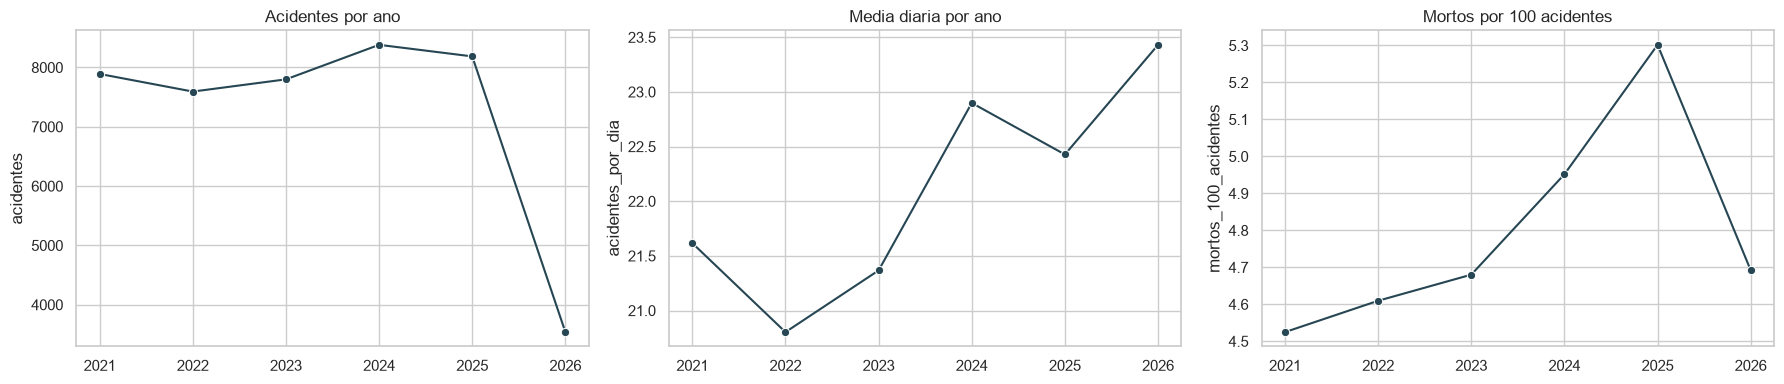

In [9]:
annual = (
    df_sc.groupby("ano")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        pessoas=("pessoas", "sum"),
        veiculos=("veiculos", "sum"),
        dias_observados=("data", "nunique"),
    )
    .reset_index()
)
annual["acidentes_por_dia"] = annual["acidentes"] / annual["dias_observados"]
annual["mortos_100_acidentes"] = annual["mortos"] / annual["acidentes"] * 100
annual["feridos_100_acidentes"] = annual["feridos"] / annual["acidentes"] * 100
display(annual)

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
sns.lineplot(data=annual, x="ano", y="acidentes", marker="o", ax=axes[0])
axes[0].set_title("Acidentes por ano")
sns.lineplot(data=annual, x="ano", y="acidentes_por_dia", marker="o", ax=axes[1])
axes[1].set_title("Media diaria por ano")
sns.lineplot(data=annual, x="ano", y="mortos_100_acidentes", marker="o", ax=axes[2])
axes[2].set_title("Mortos por 100 acidentes")
for ax in axes:
    ax.set_xlabel("")
plt.tight_layout()

mes_nome,jan,fev,mar,abr,mai,jun,jul,ago,set,out,nov,dez
ano,,,,,,,,,,,,
2021,656,623,583,634,676,702,705,622,635,663,630,761
2022,636,625,623,636,655,583,662,595,596,634,684,664
2023,653,555,670,664,662,646,666,608,663,609,632,771
2024,685,703,676,658,744,648,736,664,709,695,731,732
2025,612,619,669,678,694,641,727,695,667,711,678,795
2026,706,676,747,723,686,0,0,0,0,0,0,0


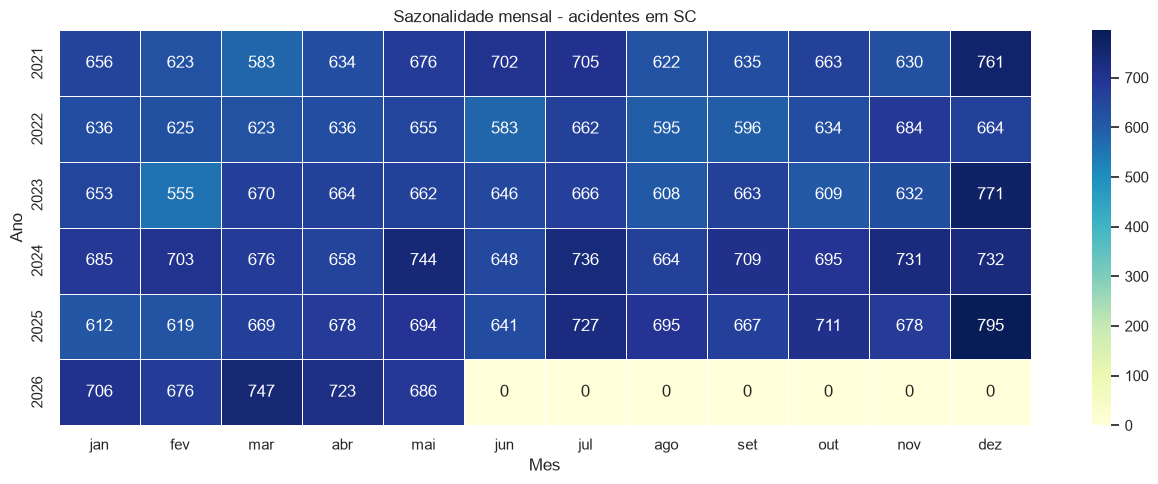

In [10]:
monthly = (
    df_sc.groupby(["ano", "mes", "mes_nome"])
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), feridos=("feridos", "sum"))
    .reset_index()
)
monthly["mes_nome"] = pd.Categorical(monthly["mes_nome"], categories=list(meses_nome.values()), ordered=True)

pivot_month = monthly.pivot_table(index="ano", columns="mes_nome", values="acidentes", aggfunc="sum", observed=False)
display(pivot_month)

plt.figure(figsize=(13, 5))
sns.heatmap(pivot_month, annot=True, fmt=".0f", cmap="YlGnBu", linewidths=.5)
plt.title("Sazonalidade mensal - acidentes em SC")
plt.xlabel("Mes")
plt.ylabel("Ano")
plt.tight_layout()

,dia_semana,acidentes,mortos,feridos,mortos_100_acidentes
0,segunda-feira,5806,267,6489,4.60
1,terça-feira,5326,212,5882,3.98
2,quarta-feira,5448,274,6043,5.03
3,quinta-feira,5640,243,6259,4.31
4,sexta-feira,6973,319,7804,4.57
5,sábado,7420,412,8456,5.55
6,domingo,6774,360,7901,5.31


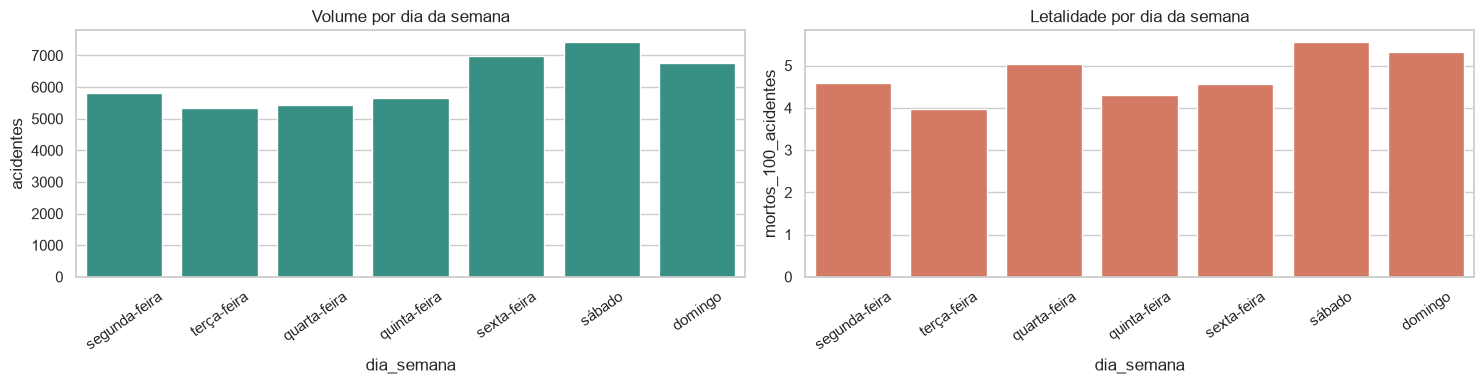

In [11]:
weekday = (
    df_sc.groupby("dia_semana_dt", observed=False)
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), feridos=("feridos", "sum"))
    .reset_index()
    .rename(columns={"dia_semana_dt": "dia_semana"})
)
weekday["mortos_100_acidentes"] = weekday["mortos"] / weekday["acidentes"] * 100
display(weekday)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
sns.barplot(data=weekday, x="dia_semana", y="acidentes", ax=axes[0], color=PALETTE[1])
axes[0].set_title("Volume por dia da semana")
axes[0].tick_params(axis="x", rotation=35)
sns.barplot(data=weekday, x="dia_semana", y="mortos_100_acidentes", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Letalidade por dia da semana")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout()

,hora,acidentes,mortos,feridos,mortos_100_acidentes
0,0,1008,57,1040,5.65
1,1,863,53,788,6.14
2,2,809,63,764,7.79
3,3,869,77,733,8.86
4,4,1037,63,933,6.08
5,5,1187,96,1231,8.09
6,6,1761,102,1908,5.79
7,7,2713,89,3145,3.28
8,8,2185,64,2524,2.93
9,9,1655,64,1886,3.87


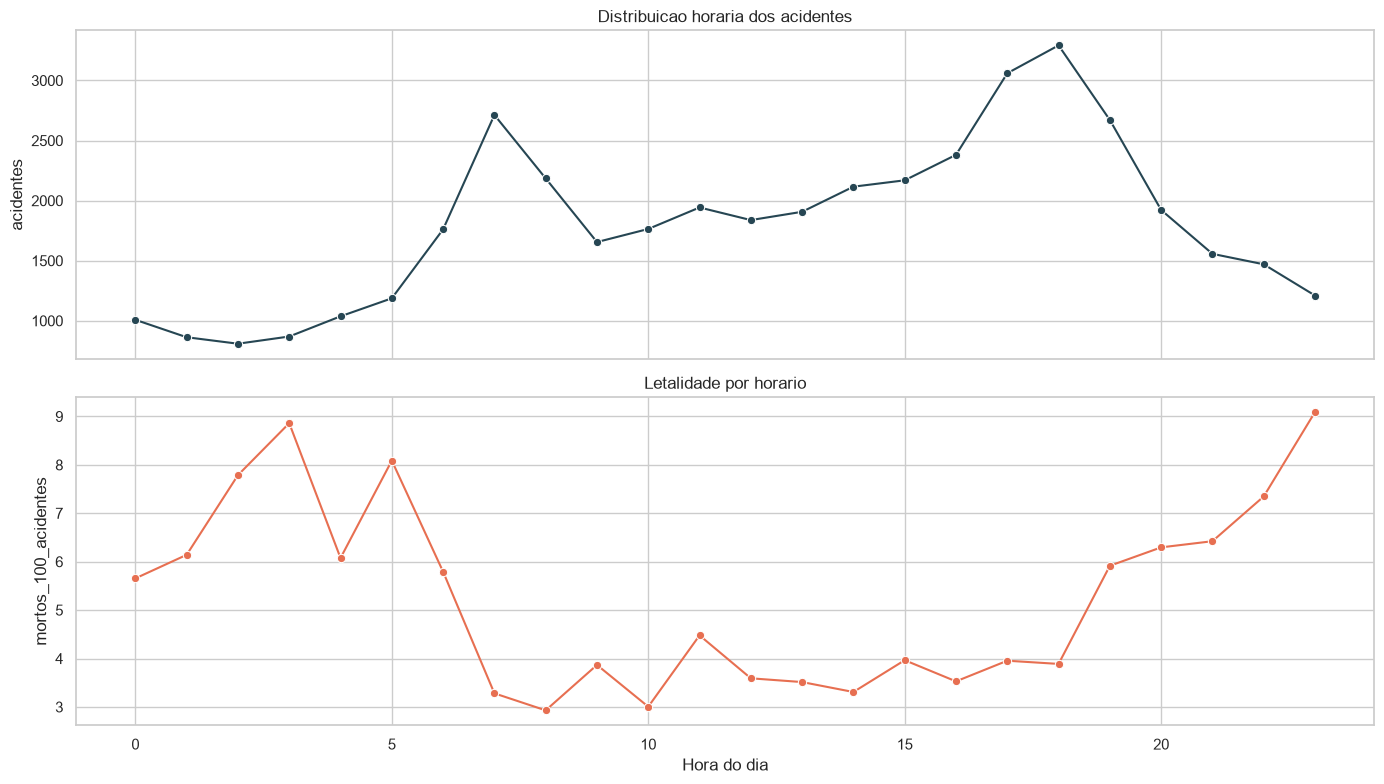

In [12]:
hourly = (
    df_sc.dropna(subset=["hora"])
    .groupby("hora")
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), feridos=("feridos", "sum"))
    .reset_index()
)
hourly["mortos_100_acidentes"] = hourly["mortos"] / hourly["acidentes"] * 100

display(hourly)

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
sns.lineplot(data=hourly, x="hora", y="acidentes", marker="o", ax=axes[0])
axes[0].set_title("Distribuicao horaria dos acidentes")
sns.lineplot(data=hourly, x="hora", y="mortos_100_acidentes", marker="o", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Letalidade por horario")
axes[1].set_xlabel("Hora do dia")
plt.tight_layout()

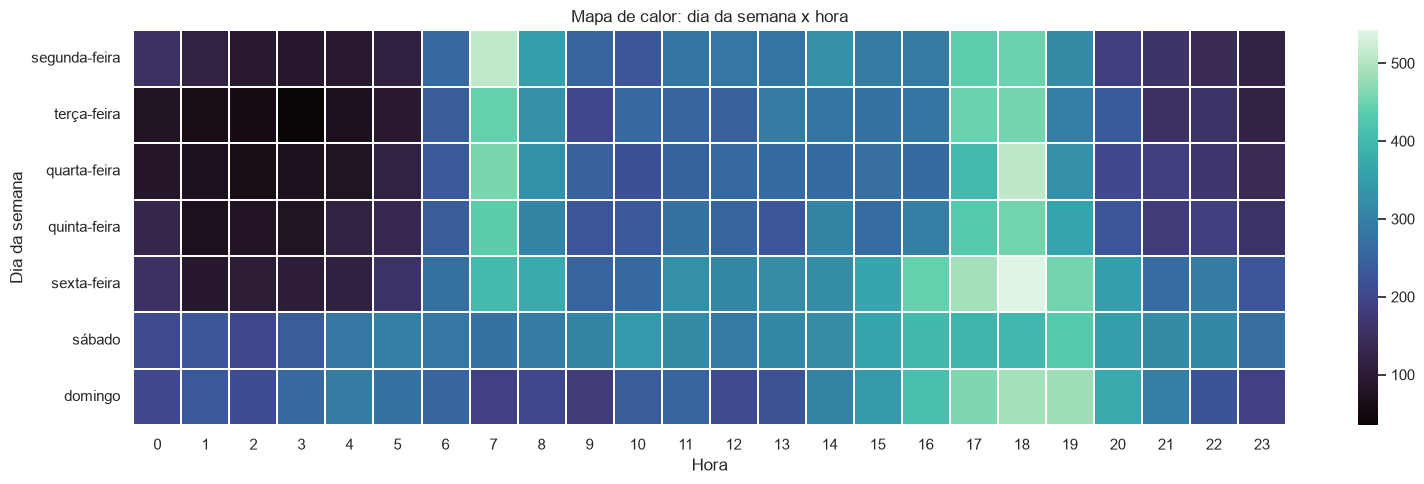

In [13]:
heat_hour_weekday = (
    df_sc.pivot_table(
        index="dia_semana_dt", columns="hora", values="id", aggfunc="count", observed=False
    )
    .fillna(0)
)

plt.figure(figsize=(16, 5))
sns.heatmap(heat_hour_weekday, cmap="mako", linewidths=.2)
plt.title("Mapa de calor: dia da semana x hora")
plt.xlabel("Hora")
plt.ylabel("Dia da semana")
plt.tight_layout()

,count,mean,min,25%,50%,75%,max,std
data,1977,2023-09-16 00:00:00,2021-01-01 00:00:00,2022-05-10 00:00:00,2023-09-16 00:00:00,2025-01-22 00:00:00,2026-05-31 00:00:00,NaN
acidentes,"1,977.00",21.95,6.00,18.00,21.00,26.00,45.00,5.93
mortos,"1,977.00",1.06,0.00,0.00,1.00,2.00,10.00,1.24
feridos,"1,977.00",24.70,6.00,19.00,24.00,29.00,78.00,8.34
feridos_graves,"1,977.00",5.63,0.00,3.00,5.00,7.00,22.00,3.16
indice_severidade,"1,977.00",41.23,8.00,30.00,39.00,50.00,122.00,15.64


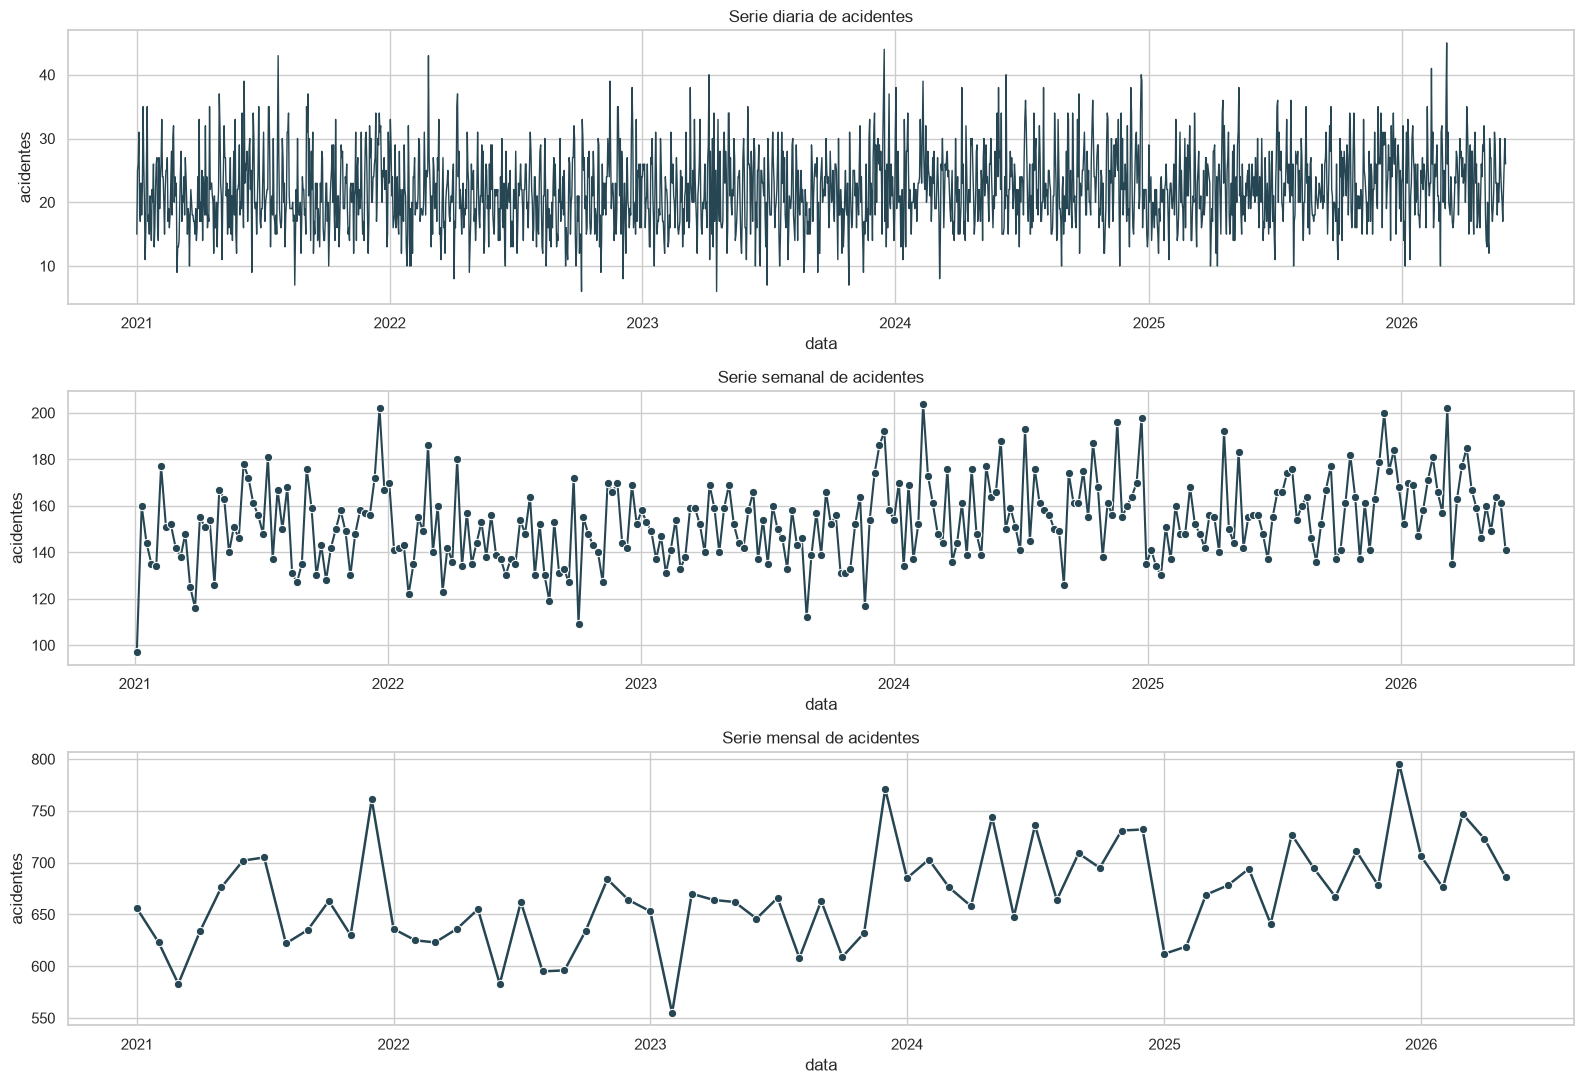

In [14]:
serie_diaria = (
    df_sc.set_index("data")
    .resample("D")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .reset_index()
)
serie_semanal = serie_diaria.set_index("data").resample("W-MON").sum().reset_index()
serie_mensal = serie_diaria.set_index("data").resample("MS").sum().reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 11), sharex=False)
sns.lineplot(data=serie_diaria, x="data", y="acidentes", ax=axes[0], linewidth=1)
axes[0].set_title("Serie diaria de acidentes")
sns.lineplot(data=serie_semanal, x="data", y="acidentes", ax=axes[1], marker="o", linewidth=1.5)
axes[1].set_title("Serie semanal de acidentes")
sns.lineplot(data=serie_mensal, x="data", y="acidentes", ax=axes[2], marker="o", linewidth=1.8)
axes[2].set_title("Serie mensal de acidentes")
plt.tight_layout()

display(serie_diaria.describe().T)

,data,acidentes,mortos,feridos,feridos_graves,indice_severidade,media_movel_7d,media_movel_30d,lag_1d,lag_7d,lag_30d
1967,2026-05-22,23,2,29,4,47,22.71,22.10,20.00,31.00,23.00
1968,2026-05-23,30,2,28,6,50,22.86,22.47,23.00,29.00,19.00
1969,2026-05-24,25,2,26,6,48,23.14,22.77,30.00,23.00,16.00
1970,2026-05-25,22,0,20,4,28,23.00,22.80,25.00,23.00,21.00
1971,2026-05-26,20,0,24,5,34,23.29,22.60,22.00,18.00,26.00
1972,2026-05-27,17,1,16,3,27,22.43,22.37,20.00,23.00,24.00
1973,2026-05-28,22,2,26,8,52,22.71,22.13,17.00,20.00,29.00
1974,2026-05-29,26,0,27,8,43,23.14,22.07,22.00,23.00,28.00
1975,2026-05-30,30,0,42,9,60,23.14,22.00,26.00,30.00,32.00
1976,2026-05-31,26,0,27,2,31,23.29,22.00,30.00,25.00,26.00


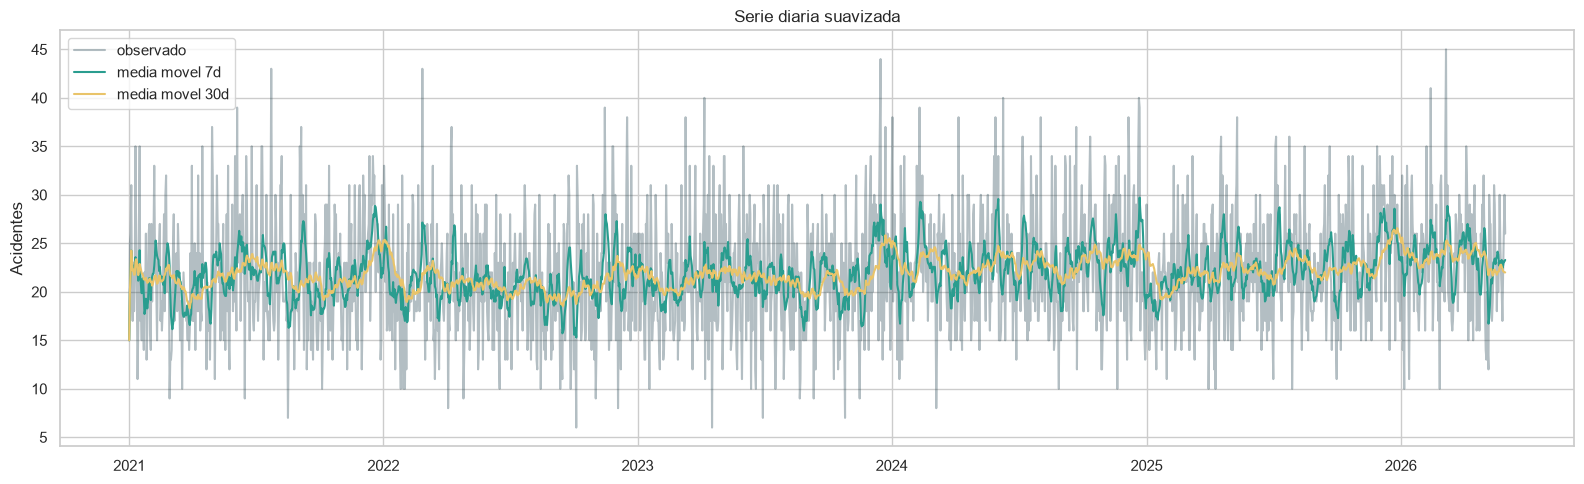

In [15]:
serie_diaria_features = serie_diaria.copy()
serie_diaria_features["media_movel_7d"] = serie_diaria_features["acidentes"].rolling(7, min_periods=1).mean()
serie_diaria_features["media_movel_30d"] = serie_diaria_features["acidentes"].rolling(30, min_periods=1).mean()
serie_diaria_features["lag_1d"] = serie_diaria_features["acidentes"].shift(1)
serie_diaria_features["lag_7d"] = serie_diaria_features["acidentes"].shift(7)
serie_diaria_features["lag_30d"] = serie_diaria_features["acidentes"].shift(30)

plt.figure(figsize=(16, 5))
sns.lineplot(data=serie_diaria_features, x="data", y="acidentes", label="observado", alpha=.35)
sns.lineplot(data=serie_diaria_features, x="data", y="media_movel_7d", label="media movel 7d")
sns.lineplot(data=serie_diaria_features, x="data", y="media_movel_30d", label="media movel 30d")
plt.title("Serie diaria suavizada")
plt.xlabel("")
plt.ylabel("Acidentes")
plt.tight_layout()

display(serie_diaria_features.tail(10))

## 5. Rodovias, municipios e trechos criticos

O objetivo aqui e localizar concentracoes relevantes. Para planejamento operacional, volume absoluto e severidade precisam ser vistos juntos: uma rodovia pode ter muitos acidentes leves, enquanto outra tem menos acidentes e maior letalidade.

,acidentes,mortos,feridos,feridos_graves,veiculos,municipios,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
br,,,,,,,,,,
101,22465,691,24080,4994,43539,49,37523,3.08,22.23,1.67
282,6997,512,8554,2093,13657,50,15300,7.32,29.91,2.19
470,6125,429,7255,1963,12463,28,13326,7.00,32.05,2.18
280,4173,211,5013,1179,8407,20,8426,5.06,28.25,2.02
116,1841,152,2001,460,3789,15,3681,8.26,24.99,2.00
163,781,21,873,183,1567,5,1344,2.69,23.43,1.72
153,438,47,532,122,974,6,1011,10.73,27.85,2.31
480,321,12,283,72,618,1,487,3.74,22.43,1.52
158,179,12,197,46,373,5,349,6.70,25.70,1.95


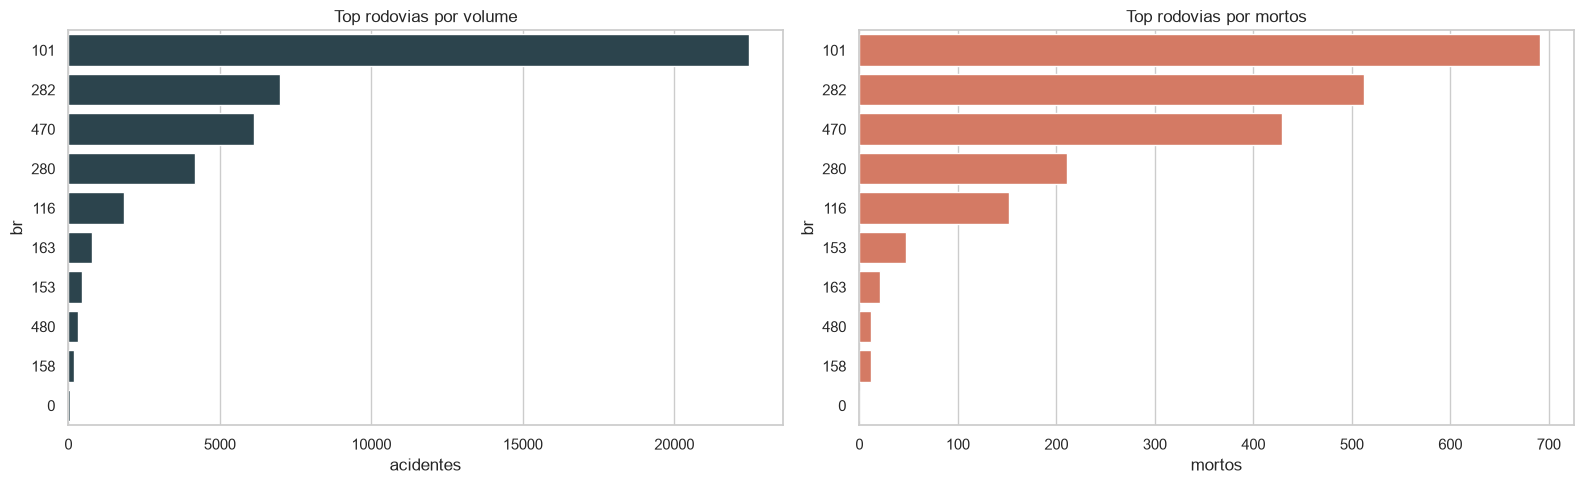

In [16]:
def add_rates(table: pd.DataFrame) -> pd.DataFrame:
    table = table.copy()
    table["mortos_100_acidentes"] = table["mortos"] / table["acidentes"] * 100
    table["feridos_graves_100_acidentes"] = table["feridos_graves"] / table["acidentes"] * 100
    table["severidade_media"] = table["indice_severidade"] / table["acidentes"]
    return table

br_summary = (
    df_sc.groupby("br")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        veiculos=("veiculos", "sum"),
        municipios=("municipio", "nunique"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)

display(br_summary.head(15))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.barplot(data=br_summary.head(10).reset_index(), y="br", x="acidentes", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Top rodovias por volume")
sns.barplot(data=br_summary.sort_values("mortos", ascending=False).head(10).reset_index(), y="br", x="mortos", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Top rodovias por mortos")
plt.tight_layout()

,acidentes,mortos,feridos,feridos_graves,brs,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
municipio,,,,,,,,,
SAO JOSE,3951,74,4217,762,3,6111,1.87,19.29,1.55
PALHOCA,3092,73,3349,861,3,5436,2.36,27.85,1.76
ITAJAI,2063,60,2164,469,3,3402,2.91,22.73,1.65
BALNEARIO CAMBORIU,1720,51,1783,429,2,2896,2.97,24.94,1.68
ARAQUARI,1594,68,1895,397,3,3029,4.27,24.91,1.90
JOINVILLE,1563,57,1691,196,2,2368,3.65,12.54,1.52
BIGUACU,1511,36,1577,245,4,2247,2.38,16.21,1.49
ITAPEMA,1271,26,1338,310,3,2088,2.05,24.39,1.64
BLUMENAU,1161,34,1237,289,2,1985,2.93,24.89,1.71


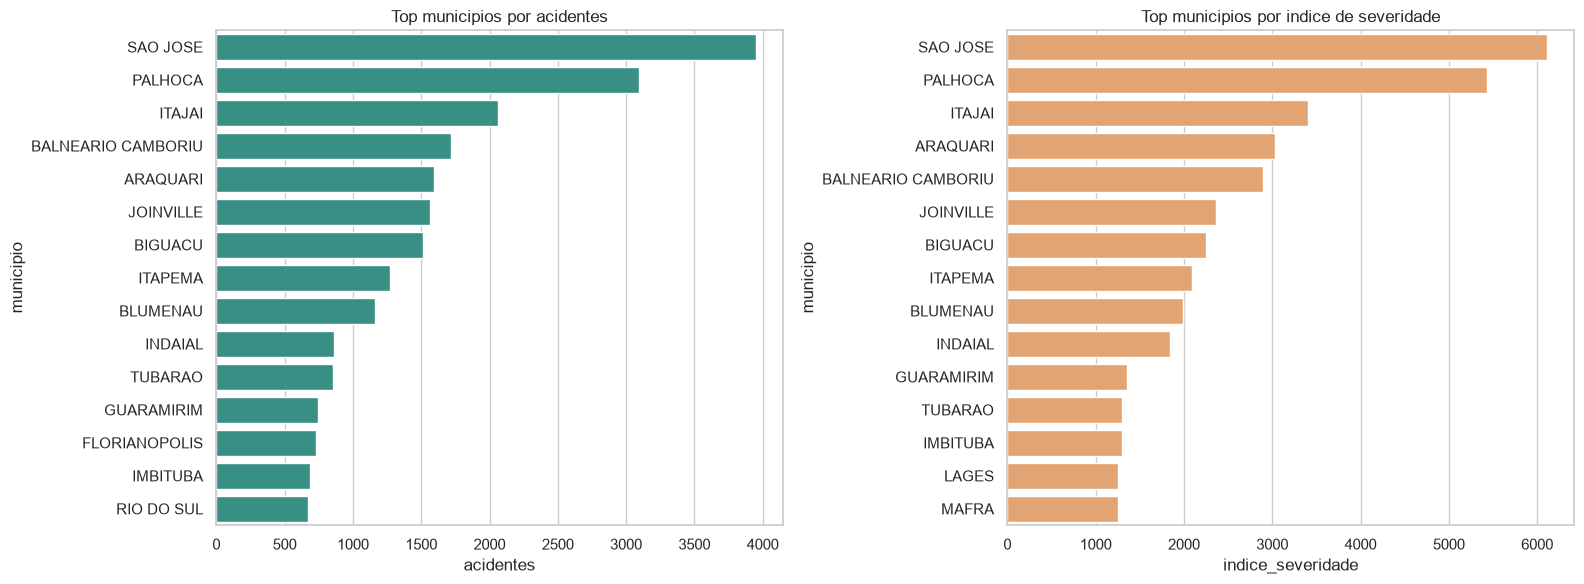

In [17]:
city_summary = (
    df_sc.groupby("municipio")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        brs=("br", "nunique"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)

display(city_summary.head(20))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sns.barplot(data=city_summary.head(15).reset_index(), y="municipio", x="acidentes", ax=axes[0], color=PALETTE[1])
axes[0].set_title("Top municipios por acidentes")
sns.barplot(data=city_summary.sort_values("indice_severidade", ascending=False).head(15).reset_index(), y="municipio", x="indice_severidade", ax=axes[1], color=PALETTE[3])
axes[1].set_title("Top municipios por indice de severidade")
plt.tight_layout()

In [18]:
city_br_summary = (
    df_sc.groupby(["municipio", "br"])
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)

display(city_br_summary.head(25))

,,acidentes,mortos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
municipio,br,,,,,,,
SAO JOSE,101,3544,67,684,5491,1.89,19.30,1.55
PALHOCA,101,2513,57,669,4307,2.27,26.62,1.71
ITAJAI,101,2055,60,467,3391,2.92,22.73,1.65
BALNEARIO CAMBORIU,101,1719,51,429,2896,2.97,24.96,1.68
JOINVILLE,101,1559,55,191,2339,3.53,12.25,1.50
BIGUACU,101,1506,36,245,2244,2.39,16.27,1.49
ITAPEMA,101,1268,26,308,2082,2.05,24.29,1.64
BLUMENAU,470,1160,34,289,1985,2.93,24.91,1.71
ARAQUARI,280,1003,29,291,1963,2.89,29.01,1.96


,br,faixa_km_10,acidentes,mortos,indice_severidade
20,101,200,3019,57,4644
21,101,210,2053,32,3412
13,101,130,1575,45,2667
11,101,110,1297,40,2062
19,101,190,1293,27,1899
14,101,140,1099,25,1797
12,101,120,1085,33,1851
15,101,150,769,16,1276
47,116,0,218,9,337
71,116,240,132,4,223


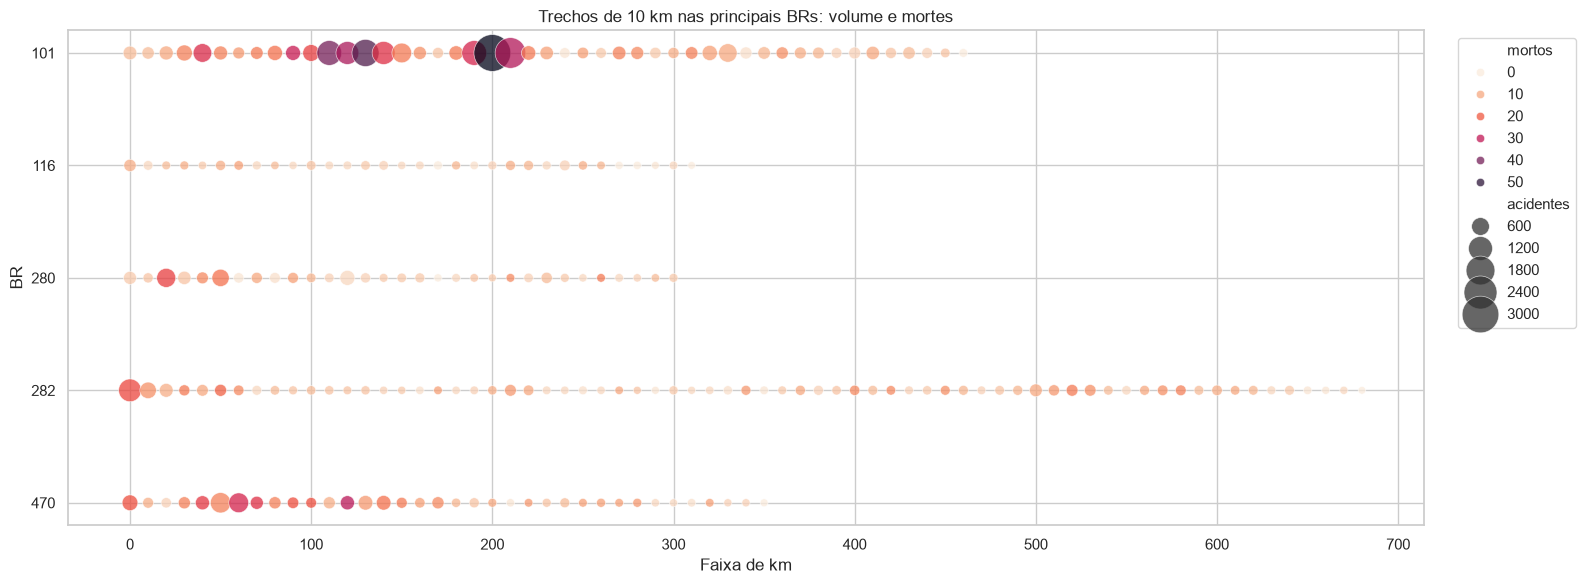

In [19]:
top_brs = br_summary.head(5).index.tolist()
km_summary = (
    df_sc[df_sc["br"].isin(top_brs) & df_sc["faixa_km_10"].notna()]
    .groupby(["br", "faixa_km_10"])
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), indice_severidade=("indice_severidade", "sum"))
    .reset_index()
)

display(
    km_summary.sort_values(["br", "acidentes"], ascending=[True, False])
    .groupby("br")
    .head(8)
    .sort_values(["br", "acidentes"], ascending=[True, False])
)

plt.figure(figsize=(16, 6))
sns.scatterplot(
    data=km_summary,
    x="faixa_km_10",
    y="br",
    size="acidentes",
    hue="mortos",
    sizes=(30, 700),
    palette="rocket_r",
    alpha=.75,
)
plt.title("Trechos de 10 km nas principais BRs: volume e mortes")
plt.xlabel("Faixa de km")
plt.ylabel("BR")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

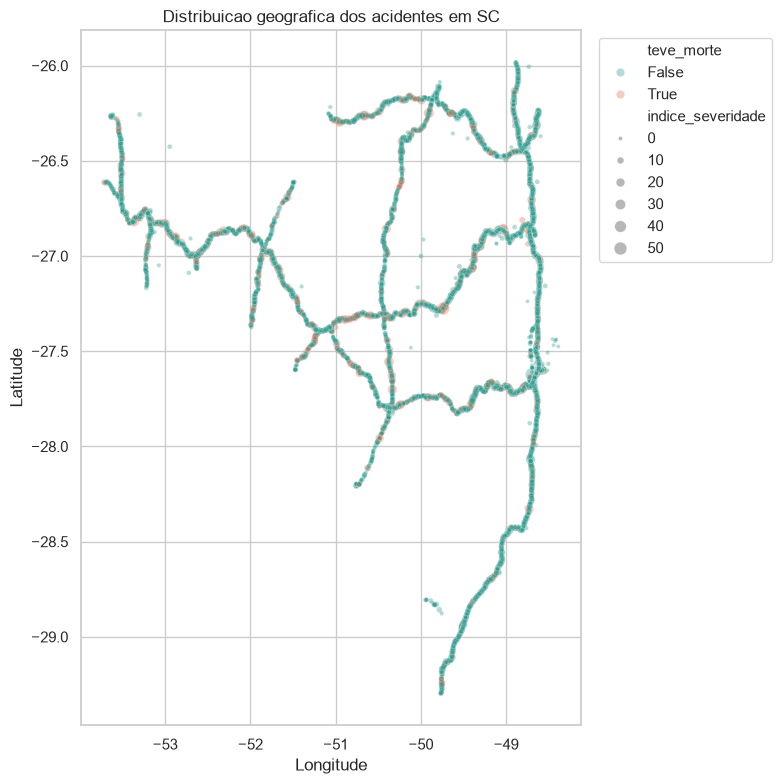

In [20]:
geo = df_sc.dropna(subset=["latitude_num", "longitude_num"]).copy()
# Limites aproximados de SC para reduzir coordenadas claramente inconsistentes.
geo = geo[geo["latitude_num"].between(-30, -25) & geo["longitude_num"].between(-54, -47)]

plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=geo,
    x="longitude_num",
    y="latitude_num",
    hue="teve_morte",
    size="indice_severidade",
    sizes=(8, 90),
    alpha=.35,
    palette={False: PALETTE[1], True: PALETTE[4]},
)
plt.title("Distribuicao geografica dos acidentes em SC")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()

## 6. Causas, tipos de acidente e severidade

A analise abaixo separa frequencia de gravidade. Essa distincao e essencial: causas muito frequentes nem sempre sao as mais letais, e causas menos frequentes podem exigir acao preventiva prioritaria por severidade.

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
causa_acidente,,,,,,,,
Reação tardia ou ineficiente do condutor,5992,200,6671,1277,10225,3.34,21.31,1.71
Ausência de reação do condutor,5168,211,5550,1275,9155,4.08,24.67,1.77
Acessar a via sem observar a presença dos outros veículos,4484,119,5511,1297,8700,2.65,28.93,1.94
Condutor deixou de manter distância do veículo da frente,3346,42,3698,627,5162,1.26,18.74,1.54
Ingestão de álcool pelo condutor,3322,63,2650,596,4157,1.90,17.94,1.25
Velocidade Incompatível,3101,239,3562,920,6597,7.71,29.67,2.13
Manobra de mudança de faixa,2768,54,3350,664,4948,1.95,23.99,1.79
Desrespeitar a preferência no cruzamento,1702,25,2131,443,3142,1.47,26.03,1.85
Demais falhas mecânicas ou elétricas,1432,19,1203,189,1676,1.33,13.20,1.17


,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
causa_acidente,,,,,,,,
Pedestre andava na pista,297,114,211,109,999,38.38,36.70,3.36
Pedestre cruzava a pista fora da faixa,264,85,241,115,896,32.20,43.56,3.39
Transitar na contramão,1392,378,1981,793,5457,27.16,56.97,3.92
Entrada inopinada do pedestre,247,62,224,103,740,25.10,41.70,3.00
Ultrapassagem Indevida,1031,118,1428,475,2968,11.45,46.07,2.88
Mal súbito do condutor,363,40,402,83,768,11.02,22.87,2.12
Velocidade Incompatível,3101,239,3562,920,6597,7.71,29.67,2.13
Condutor Dormindo,958,54,1181,266,1983,5.64,27.77,2.07
Transitar no Acostamento,110,6,115,42,229,5.45,38.18,2.08


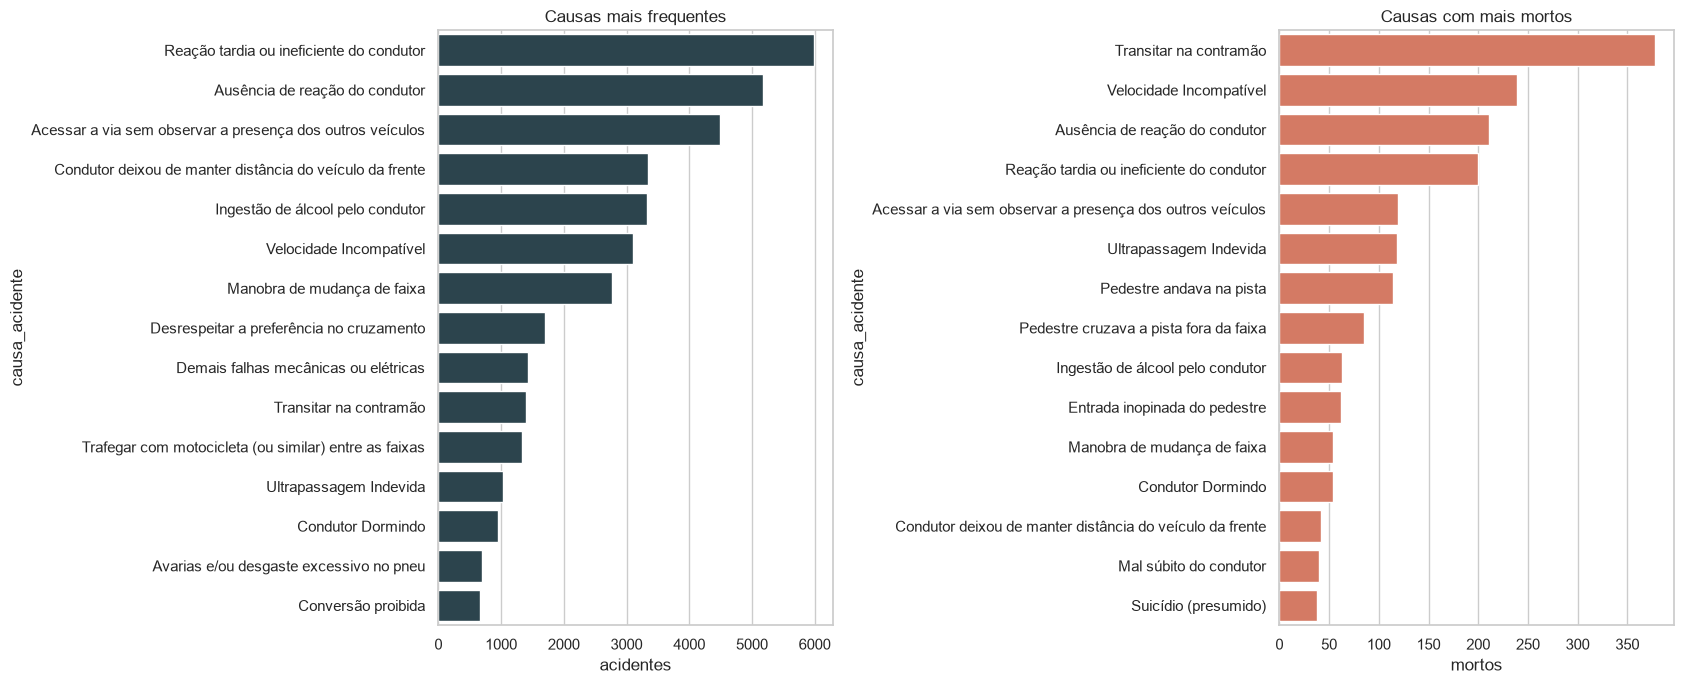

In [21]:
cause_summary = (
    df_sc.groupby("causa_acidente")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)

display(cause_summary.head(20))
display(cause_summary.query("acidentes >= 100").sort_values("mortos_100_acidentes", ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.barplot(data=cause_summary.head(15).reset_index(), y="causa_acidente", x="acidentes", ax=axes[0], color=PALETTE[0])
axes[0].set_title("Causas mais frequentes")
sns.barplot(data=cause_summary.sort_values("mortos", ascending=False).head(15).reset_index(), y="causa_acidente", x="mortos", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Causas com mais mortos")
plt.tight_layout()

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
tipo_acidente,,,,,,,,
Colisão traseira,8856,222,9855,2053,15071,2.51,23.18,1.70
Colisão transversal,6825,152,8509,2066,13401,2.23,30.27,1.96
Colisão lateral mesmo sentido,5712,87,6260,1157,9009,1.52,20.26,1.58
Saída de leito carroçável,5572,197,5508,1025,8543,3.54,18.40,1.53
Tombamento,3664,105,4223,751,6250,2.87,20.50,1.71
Colisão com objeto,3588,125,3299,679,5282,3.48,18.92,1.47
Colisão frontal,2843,741,4687,1839,12070,26.06,64.69,4.25
Queda de ocupante de veículo,1412,16,1660,273,2286,1.13,19.33,1.62
Atropelamento de Pedestre,1280,332,1183,562,3967,25.94,43.91,3.10


,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
tipo_acidente,,,,,,,,
Colisão frontal,2843,741,4687,1839,12070,26.06,64.69,4.25
Atropelamento de Pedestre,1280,332,1183,562,3967,25.94,43.91,3.10
Colisão lateral sentido oposto,1097,67,1337,360,2392,6.11,32.82,2.18
Saída de leito carroçável,5572,197,5508,1025,8543,3.54,18.40,1.53
Colisão com objeto,3588,125,3299,679,5282,3.48,18.92,1.47
Tombamento,3664,105,4223,751,6250,2.87,20.50,1.71
Engavetamento,702,18,913,109,1221,2.56,15.53,1.74
Colisão traseira,8856,222,9855,2053,15071,2.51,23.18,1.70
Atropelamento de Animal,219,5,232,46,349,2.28,21.00,1.59


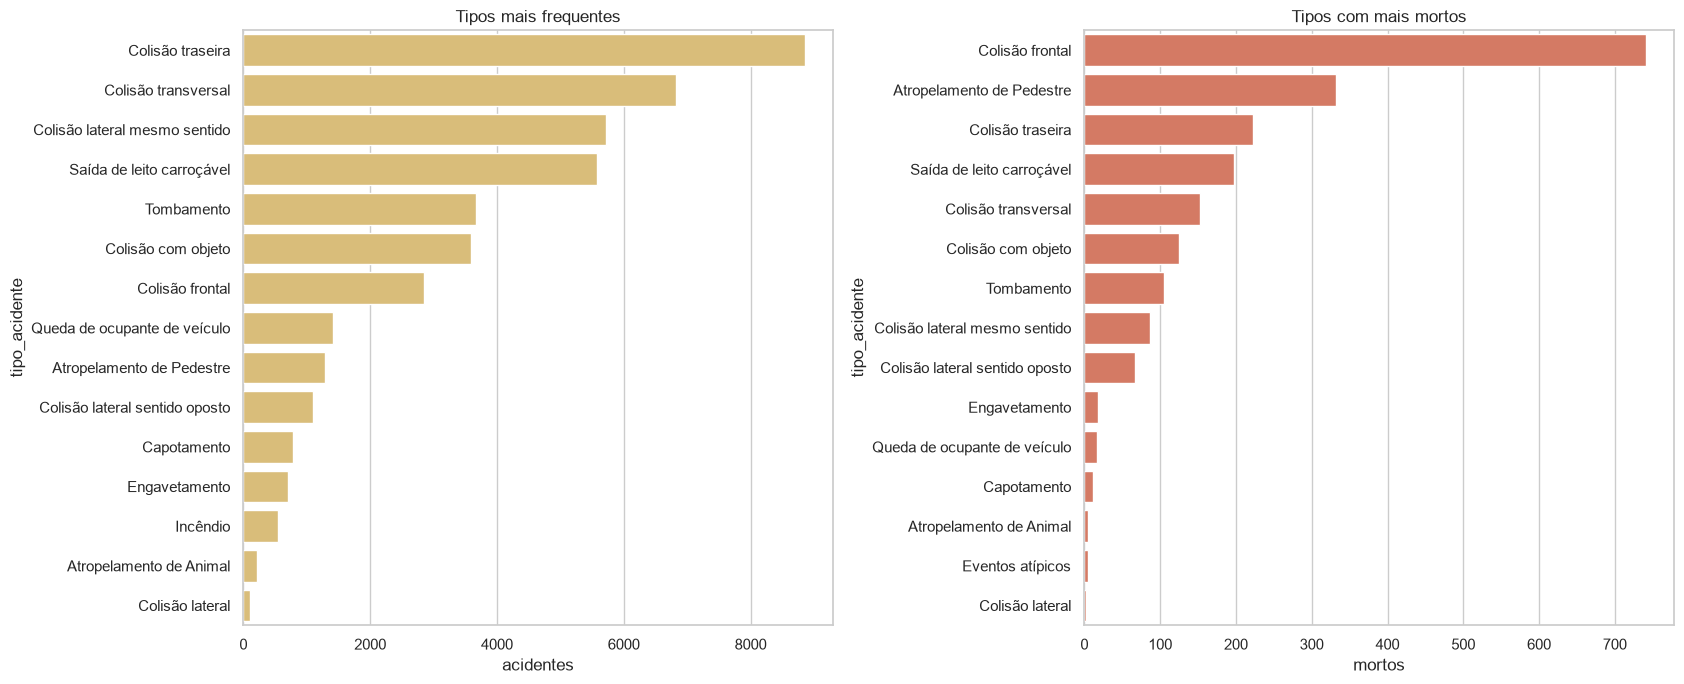

In [22]:
type_summary = (
    df_sc.groupby("tipo_acidente")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)

display(type_summary.head(20))
display(type_summary.query("acidentes >= 100").sort_values("mortos_100_acidentes", ascending=False).head(20))

fig, axes = plt.subplots(1, 2, figsize=(17, 7))
sns.barplot(data=type_summary.head(15).reset_index(), y="tipo_acidente", x="acidentes", ax=axes[0], color=PALETTE[2])
axes[0].set_title("Tipos mais frequentes")
sns.barplot(data=type_summary.sort_values("mortos", ascending=False).head(15).reset_index(), y="tipo_acidente", x="mortos", ax=axes[1], color=PALETTE[4])
axes[1].set_title("Tipos com mais mortos")
plt.tight_layout()

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
classificacao_acidente,,,,,,,,
Com Vítimas Feridas,34898,0,47440,10445,68330,0.00,29.93,1.96
Sem Vítimas,6674,0,0,0,0,0.00,0.00,0.00
Com Vítimas Fatais,1815,2087,1394,681,13191,114.99,37.52,7.27


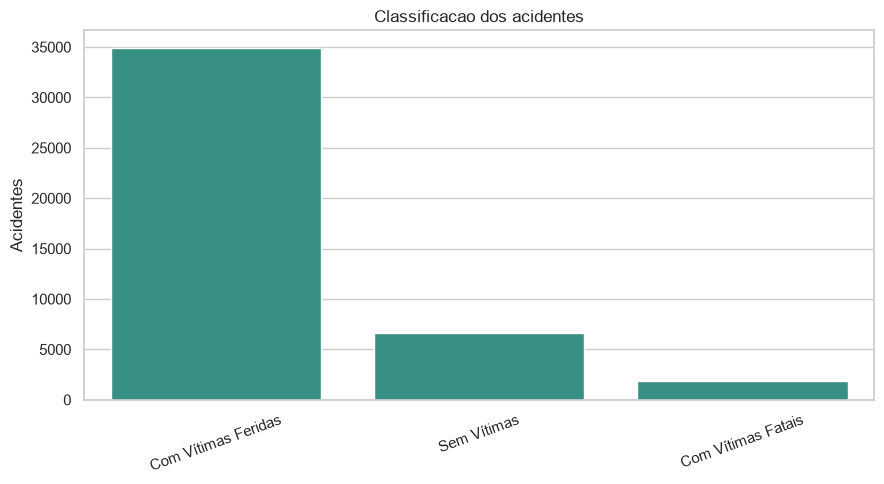

In [23]:
classification = (
    df_sc.groupby("classificacao_acidente")
    .agg(
        acidentes=("id", "size"),
        mortos=("mortos", "sum"),
        feridos=("feridos", "sum"),
        feridos_graves=("feridos_graves", "sum"),
        indice_severidade=("indice_severidade", "sum"),
    )
    .pipe(add_rates)
    .sort_values("acidentes", ascending=False)
)
display(classification)

plt.figure(figsize=(9, 5))
sns.barplot(data=classification.reset_index(), x="classificacao_acidente", y="acidentes", color=PALETTE[1])
plt.title("Classificacao dos acidentes")
plt.xlabel("")
plt.ylabel("Acidentes")
plt.xticks(rotation=20)
plt.tight_layout()

## 7. Condicoes de ambiente e caracteristicas da via

Essas variaveis ajudam a entender contexto operacional: clima, fase do dia, tipo de pista, tracado e uso do solo. Para modelagem, algumas podem nao estar disponiveis antes do acidente; por isso elas servem mais para explicacao historica e planejamento do que para previsao pura, a menos que sejam substituidas por fontes externas previsiveis.

In [24]:
def summarize_category(col: str, min_accidents: int = 0) -> pd.DataFrame:
    out = (
        df_sc.groupby(col)
        .agg(
            acidentes=("id", "size"),
            mortos=("mortos", "sum"),
            feridos=("feridos", "sum"),
            feridos_graves=("feridos_graves", "sum"),
            indice_severidade=("indice_severidade", "sum"),
        )
        .pipe(add_rates)
        .sort_values("acidentes", ascending=False)
    )
    if min_accidents:
        out = out[out["acidentes"] >= min_accidents]
    return out

for col in ["condicao_metereologica", "fase_dia", "tipo_pista", "tracado_via", "uso_solo", "sentido_via"]:
    display(Markdown(f"### {col}"))
    display(summarize_category(col).head(20))

### condicao_metereologica

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
condicao_metereologica,,,,,,,,
Céu Claro,22246,970,25026,5994,41864,4.36,26.94,1.88
Nublado,10076,540,11170,2590,19050,5.36,25.70,1.89
Chuva,5276,291,6046,1210,9921,5.52,22.93,1.88
Garoa/Chuvisco,2543,135,2860,576,4687,5.31,22.65,1.84
Sol,2363,92,2845,546,4397,3.89,23.11,1.86
Nevoeiro/Neblina,504,39,549,122,988,7.74,24.21,1.96
Ignorado,363,18,323,88,589,4.96,24.24,1.62
Vento,15,2,14,0,24,13.33,0.00,1.60
Neve,1,0,1,0,1,0.00,0.00,1.00


### fase_dia

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
fase_dia,,,,,,,,
Pleno dia,24236,868,28634,5952,44878,3.58,24.56,1.85
Plena Noite,15123,1004,15656,4081,28838,6.64,26.99,1.91
Anoitecer,2245,82,2656,640,4346,3.65,28.51,1.94
Amanhecer,1783,133,1888,453,3459,7.46,25.41,1.94


### tipo_pista

...

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
tracado_via,,,,,,,,
Reta,24008,911,26479,5957,42948,3.79,24.81,1.79
Curva,5443,332,6333,1454,10901,6.10,26.71,2.00
Interseção de Vias,1919,21,2164,432,3133,1.09,22.51,1.63
Rotatória,1024,12,1067,160,1447,1.17,15.62,1.41
Reta;Declive,729,66,854,195,1574,9.05,26.75,2.16
Reta;Aclive,719,78,808,237,1672,10.85,32.96,2.33
Reta;Interseção de Vias,678,26,800,197,1324,3.83,29.06,1.95
Aclive;Reta,648,71,749,181,1466,10.96,27.93,2.26
Curva;Declive,631,82,802,197,1606,13.00,31.22,2.55


### uso_solo

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
uso_solo,,,,,,,,
Sim,21764,702,23840,5220,37790,3.23,23.98,1.74
Não,21623,1385,24994,5906,43731,6.41,27.31,2.02


### sentido_via

,acidentes,mortos,feridos,feridos_graves,indice_severidade,mortos_100_acidentes,feridos_graves_100_acidentes,severidade_media
sentido_via,,,,,,,,
Crescente,22782,1069,25763,5918,42944,4.69,25.98,1.88
Decrescente,20554,1018,23046,5202,38540,4.95,25.31,1.88
Não Informado,51,0,25,6,37,0.00,11.76,0.73


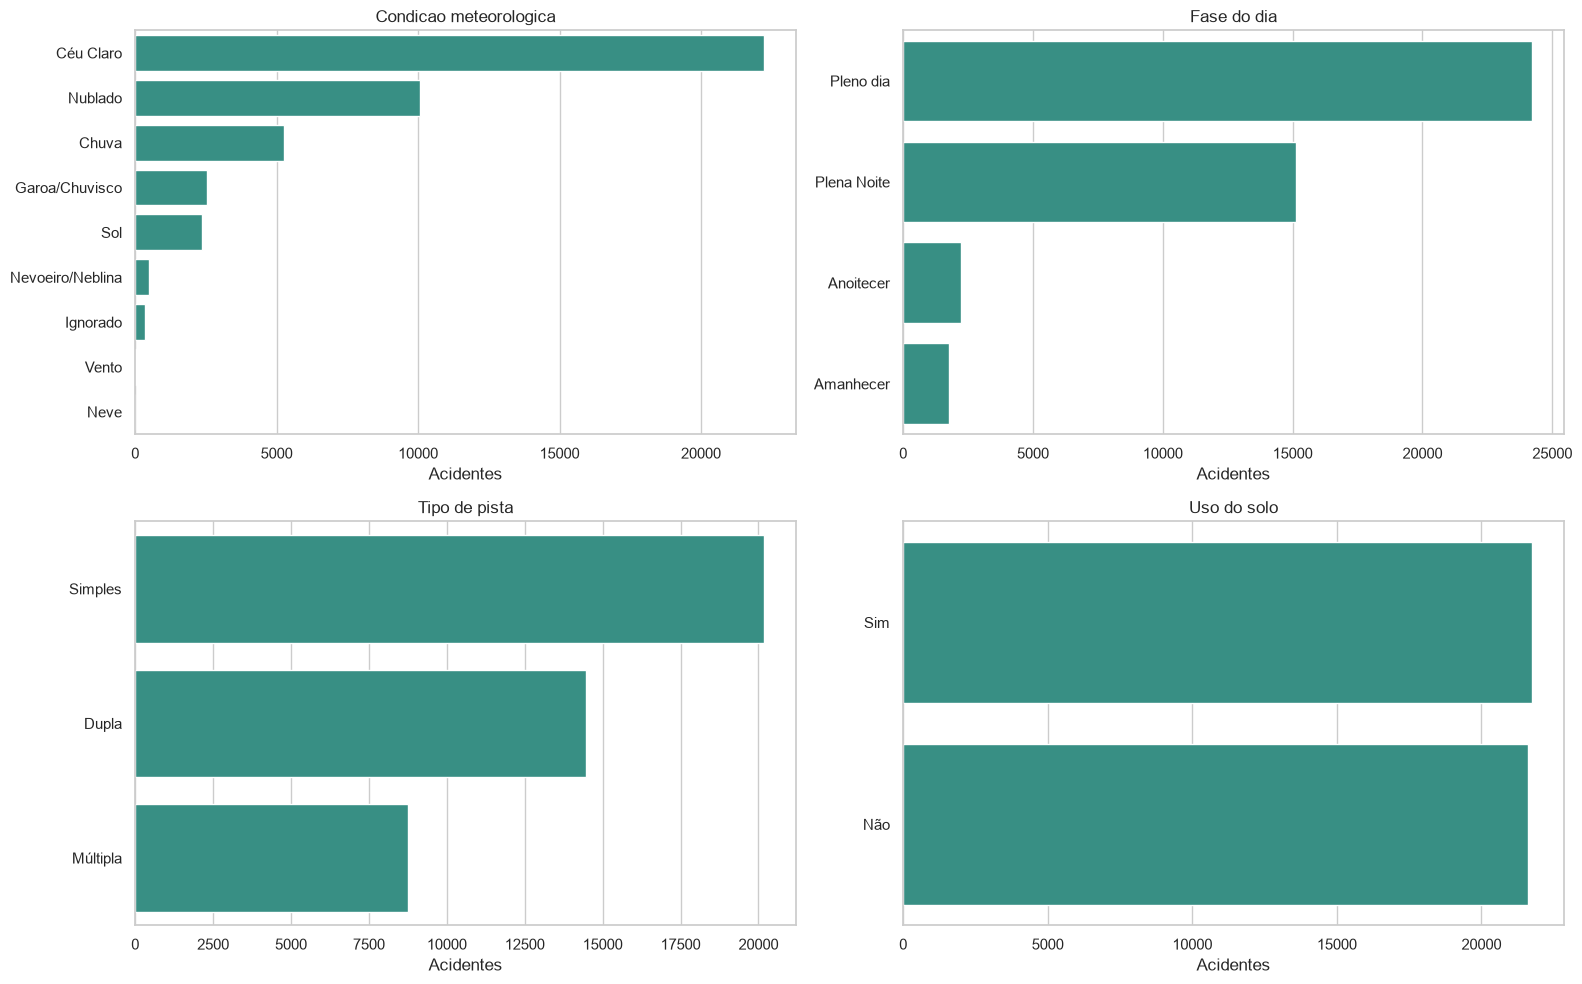

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, col, title in zip(
    axes.ravel(),
    ["condicao_metereologica", "fase_dia", "tipo_pista", "uso_solo"],
    ["Condicao meteorologica", "Fase do dia", "Tipo de pista", "Uso do solo"],
):
    plot_data = summarize_category(col).head(10).reset_index()
    sns.barplot(data=plot_data, y=col, x="acidentes", ax=ax, color=PALETTE[1])
    ax.set_title(title)
    ax.set_xlabel("Acidentes")
    ax.set_ylabel("")
plt.tight_layout()

## 8. Cruzamentos relevantes para planejamento

Os cruzamentos abaixo procuram combinacoes de maior risco: rodovia por mes, rodovia por dia da semana, periodo do dia por severidade e causas por rodovia. Essas tabelas ajudam a transformar a EDA em hipoteses de acao.

mes,1,2,3,4,5,6,7,8,9,10,11,12
br,,,,,,,,,,,,
101,2176,1973,2018,1997,2115,1572,1784,1604,1717,1750,1794,1965
116,125,178,157,173,179,160,157,150,137,141,136,148
280,389,297,410,421,398,331,343,318,308,299,299,360
282,590,629,628,681,674,528,551,532,538,546,503,597
470,527,566,605,561,595,468,495,456,431,440,469,512


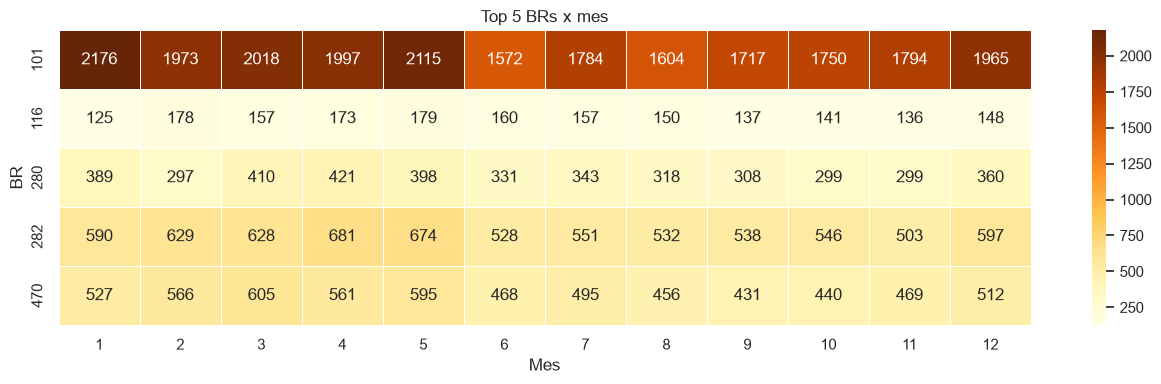

In [26]:
top5_brs = br_summary.head(5).index.tolist()

br_month = (
    df_sc[df_sc["br"].isin(top5_brs)]
    .pivot_table(index="br", columns="mes", values="id", aggfunc="count", observed=False)
    .fillna(0)
)

plt.figure(figsize=(13, 4))
sns.heatmap(br_month, annot=True, fmt=".0f", cmap="YlOrBr", linewidths=.5)
plt.title("Top 5 BRs x mes")
plt.xlabel("Mes")
plt.ylabel("BR")
plt.tight_layout()

display(br_month)

dia_semana_dt,segunda-feira,terça-feira,quarta-feira,quinta-feira,sexta-feira,sábado,domingo
br,,,,,,,
101,3060,2838,2910,2954,3527,3701,3475
116,252,214,221,243,272,332,307
280,542,518,553,502,747,717,594
282,938,816,818,902,1125,1230,1168
470,780,725,708,785,1045,1107,975


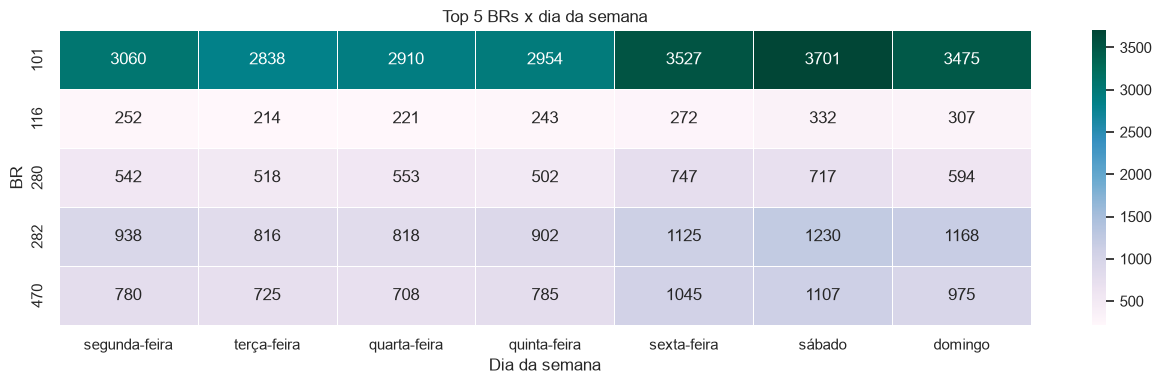

In [27]:
br_weekday = (
    df_sc[df_sc["br"].isin(top5_brs)]
    .pivot_table(index="br", columns="dia_semana_dt", values="id", aggfunc="count", observed=False)
    .fillna(0)
)

plt.figure(figsize=(13, 4))
sns.heatmap(br_weekday, annot=True, fmt=".0f", cmap="PuBuGn", linewidths=.5)
plt.title("Top 5 BRs x dia da semana")
plt.xlabel("Dia da semana")
plt.ylabel("BR")
plt.tight_layout()

display(br_weekday)

classificacao_acidente,Com Vítimas Fatais,Com Vítimas Feridas,Sem Vítimas
periodo_hora,,,
madrugada,352.00,"3,654.00","1,767.00"
manha,385.00,"10,243.00","1,393.00"
tarde,419.00,"11,536.00","1,516.00"
noite,659.00,"9,465.00","1,998.00"


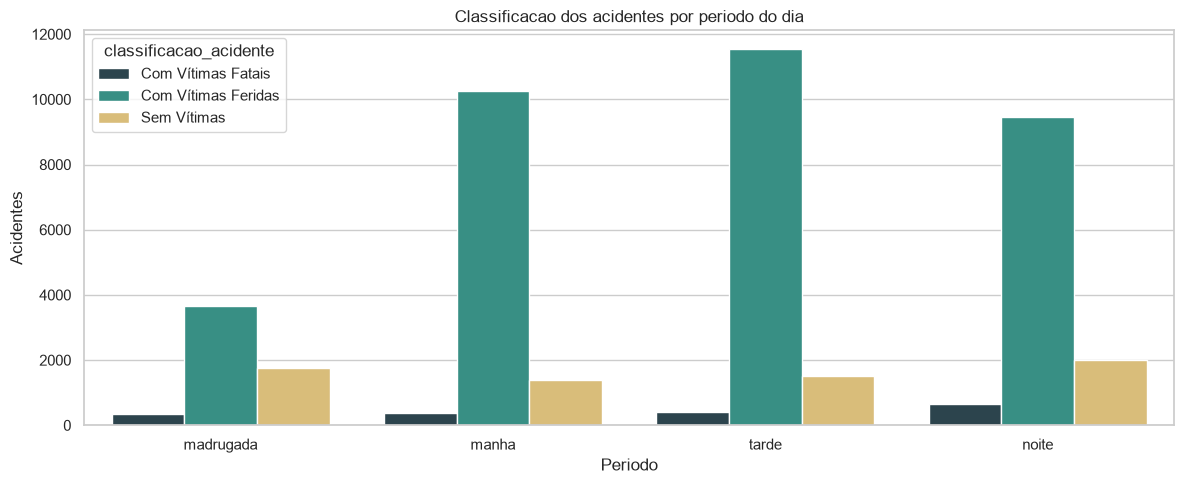

In [28]:
period_severity = (
    df_sc.groupby(["periodo_hora", "classificacao_acidente"], observed=False)
    .size()
    .reset_index(name="acidentes")
)

plt.figure(figsize=(12, 5))
sns.barplot(data=period_severity, x="periodo_hora", y="acidentes", hue="classificacao_acidente")
plt.title("Classificacao dos acidentes por periodo do dia")
plt.xlabel("Periodo")
plt.ylabel("Acidentes")
plt.tight_layout()

display(period_severity.pivot_table(index="periodo_hora", columns="classificacao_acidente", values="acidentes", fill_value=0, observed=False))

In [29]:
cause_by_br = (
    df_sc[df_sc["br"].isin(top5_brs)]
    .groupby(["br", "causa_acidente"])
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), indice_severidade=("indice_severidade", "sum"))
    .reset_index()
    .sort_values(["br", "acidentes"], ascending=[True, False])
)

display(cause_by_br.groupby("br").head(8))

,br,causa_acidente,acidentes,mortos,indice_severidade
55,101,Reação tardia ou ineficiente do condutor,3691,79,5975
8,101,Ausência de reação do condutor,3015,94,5034
14,101,Condutor deixou de manter distância do veículo...,2204,30,3443
40,101,Manobra de mudança de faixa,2075,21,3539
38,101,Ingestão de álcool pelo condutor,1645,18,1683
0,101,Acessar a via sem observar a presença dos outr...,1487,39,2516
72,101,Velocidade Incompatível,1188,56,2183
65,101,Trafegar com motocicleta (ou similar) entre as...,958,30,1731
74,116,Acessar a via sem observar a presença dos outr...,248,11,531
116,116,Reação tardia ou ineficiente do condutor,237,12,402


## 9. Base analitica para modelagem temporal

Para a etapa de Machine Learning, a variavel-alvo mais natural e `acidentes` por data. Tambem e util criar bases por rodovia e por municipio quando houver volume suficiente.

Cuidados importantes:

- Usar divisao temporal de treino/teste, nunca embaralhar aleatoriamente a serie.
- Tratar 2026 como ano possivelmente incompleto, dependendo da data maxima do arquivo.
- Variaveis como clima e causa do acidente podem ser indisponiveis antes da ocorrencia; para previsao operacional, priorizar calendario, historico defasado, feriados e previsoes externas.
- Avaliar modelos por MAE, RMSE e MAPE/sMAPE, comparando contra baselines simples como media movel e valor da semana anterior.

In [30]:
model_daily = serie_diaria_features.copy()
model_daily["ano"] = model_daily["data"].dt.year
model_daily["mes"] = model_daily["data"].dt.month
model_daily["dia_semana"] = model_daily["data"].dt.dayofweek
model_daily["dia_do_mes"] = model_daily["data"].dt.day
model_daily["semana_iso"] = model_daily["data"].dt.isocalendar().week.astype(int)
model_daily["fim_de_semana"] = model_daily["dia_semana"].isin([5, 6]).astype(int)

cutoff = model_daily["data"].max() - pd.Timedelta(days=180)
model_daily["split_sugerido"] = np.where(model_daily["data"] <= cutoff, "treino", "teste_ultimos_180d")

display(model_daily.tail(15))
display(model_daily["split_sugerido"].value_counts())

,data,acidentes,mortos,feridos,feridos_graves,indice_severidade,media_movel_7d,media_movel_30d,lag_1d,lag_7d,lag_30d,ano,mes,dia_semana,dia_do_mes,semana_iso,fim_de_semana,split_sugerido
1962,2026-05-17,23,0,20,6,32,22.86,22.03,29.00,27.00,31.00,2026,5,6,17,20,1,teste_ultimos_180d
1963,2026-05-18,23,0,29,7,43,23.43,22.03,23.00,19.00,23.00,2026,5,0,18,21,0,teste_ultimos_180d
1964,2026-05-19,18,4,20,6,52,23.57,21.77,23.00,17.00,26.00,2026,5,1,19,21,0,teste_ultimos_180d
1965,2026-05-20,23,1,26,8,47,24.14,22.00,18.00,19.00,16.00,2026,5,2,20,21,0,teste_ultimos_180d
1966,2026-05-21,20,1,27,7,46,23.86,22.10,23.00,22.00,17.00,2026,5,3,21,21,0,teste_ultimos_180d
1967,2026-05-22,23,2,29,4,47,22.71,22.10,20.00,31.00,23.00,2026,5,4,22,21,0,teste_ultimos_180d
1968,2026-05-23,30,2,28,6,50,22.86,22.47,23.00,29.00,19.00,2026,5,5,23,21,1,teste_ultimos_180d
1969,2026-05-24,25,2,26,6,48,23.14,22.77,30.00,23.00,16.00,2026,5,6,24,21,1,teste_ultimos_180d
1970,2026-05-25,22,0,20,4,28,23.00,22.80,25.00,23.00,21.00,2026,5,0,25,22,0,teste_ultimos_180d
1971,2026-05-26,20,0,24,5,34,23.29,22.60,22.00,18.00,26.00,2026,5,1,26,22,0,teste_ultimos_180d


split_sugerido
treino                1797
teste_ultimos_180d     180
Name: count, dtype: int64

In [31]:
br_daily = (
    df_sc.groupby(["data", "br"])
    .agg(acidentes=("id", "size"), mortos=("mortos", "sum"), feridos=("feridos", "sum"), indice_severidade=("indice_severidade", "sum"))
    .reset_index()
)

# Mantem rodovias com volume suficiente para modelos por BR.
min_acidentes_br = 500
brs_modelaveis = br_summary.query("acidentes >= @min_acidentes_br").index.tolist()
br_daily_model = br_daily[br_daily["br"].isin(brs_modelaveis)].copy()

# Completa datas faltantes por BR com zero acidente, necessario para serie temporal regular.
full_index = pd.MultiIndex.from_product(
    [pd.date_range(df_sc["data"].min(), df_sc["data"].max(), freq="D"), brs_modelaveis],
    names=["data", "br"],
)
br_daily_model = (
    br_daily_model.set_index(["data", "br"])
    .reindex(full_index, fill_value=0)
    .reset_index()
)

br_daily_model["lag_1d_br"] = br_daily_model.groupby("br")["acidentes"].shift(1)
br_daily_model["lag_7d_br"] = br_daily_model.groupby("br")["acidentes"].shift(7)
br_daily_model["media_7d_br"] = br_daily_model.groupby("br")["acidentes"].transform(lambda s: s.rolling(7, min_periods=1).mean())

display(br_daily_model.head(10))
display(br_daily_model.groupby("br")["acidentes"].sum().sort_values(ascending=False))

,data,br,acidentes,mortos,feridos,indice_severidade,lag_1d_br,lag_7d_br,media_7d_br
0,2021-01-01,101,8,0,15,17,NaN,NaN,8.00
1,2021-01-01,282,1,0,4,6,NaN,NaN,1.00
2,2021-01-01,470,5,2,13,31,NaN,NaN,5.00
3,2021-01-01,280,1,0,1,1,NaN,NaN,1.00
4,2021-01-01,116,0,0,0,0,NaN,NaN,0.00
5,2021-01-01,163,0,0,0,0,NaN,NaN,0.00
6,2021-01-02,101,14,0,18,30,8.00,NaN,11.00
7,2021-01-02,282,4,1,5,12,1.00,NaN,2.50
8,2021-01-02,470,3,0,7,7,5.00,NaN,4.00
9,2021-01-02,280,3,0,3,3,1.00,NaN,2.00


br
101    22465
282     6997
470     6125
280     4173
116     1841
163      781
Name: acidentes, dtype: int64

In [32]:
# Opcional: salvar bases analiticas para a proxima etapa.
# PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
# model_daily.to_csv(PROCESSED_DIR / "serie_diaria_sc.csv", index=False)
# br_daily_model.to_csv(PROCESSED_DIR / "serie_diaria_por_br_sc.csv", index=False)

## 10. Principais achados gerados automaticamente

A celula abaixo produz uma sintese textual com os achados centrais da base carregada. Ela deve ser reexecutada sempre que novos arquivos forem adicionados ou atualizados.

In [33]:
def top_name(summary: pd.DataFrame, metric: str) -> str:
    idx = summary[metric].idxmax()
    val = summary.loc[idx, metric]
    return f"{idx} ({val:,.0f})"

last_year = int(df_sc["ano"].max())
last_year_days = int(df_sc.loc[df_sc["ano"].eq(last_year), "data"].nunique())
complete_years = annual.loc[annual["dias_observados"] >= 360]
peak_complete_year = complete_years.sort_values("acidentes", ascending=False).iloc[0]
peak_month = monthly.groupby("mes_nome", observed=False)["acidentes"].sum().sort_values(ascending=False).index[0]
peak_hour = hourly.sort_values("acidentes", ascending=False).iloc[0]
most_lethal_cause = cause_summary.query("acidentes >= 100").sort_values("mortos_100_acidentes", ascending=False).iloc[0]
most_lethal_type = type_summary.query("acidentes >= 100").sort_values("mortos_100_acidentes", ascending=False).iloc[0]

summary_text = f"""
### Sintese executiva

- A base consolidada contem **{len(df):,} registros no Brasil** e **{len(df_sc):,} registros em Santa Catarina**, o que representa **{len(df_sc) / len(df) * 100:.2f}%** do total disponivel.
- O periodo observado em SC vai de **{df_sc['data'].min().date()}** a **{df_sc['data'].max().date()}**. O ano mais recente da base e **{last_year}**, com **{last_year_days} dias observados**, entao a comparacao anual deve considerar cobertura parcial quando esse numero for menor que 365.
- Entre os anos completos, o maior volume anual foi **{int(peak_complete_year['ano'])}**, com **{peak_complete_year['acidentes']:,.0f} acidentes**.
- A rodovia com maior volume e **BR-{top_name(br_summary, 'acidentes')}**; a rodovia com mais mortes e **BR-{top_name(br_summary, 'mortos')}**.
- O municipio com mais acidentes e **{top_name(city_summary, 'acidentes')}**; o municipio com maior indice de severidade agregado e **{top_name(city_summary, 'indice_severidade')}**.
- O mes historicamente mais carregado e **{peak_month}** e o horario com maior volume e **{int(peak_hour['hora']):02d}h**, com **{peak_hour['acidentes']:,.0f} acidentes**.
- A causa mais frequente e **{cause_summary.index[0]}**. Entre causas com pelo menos 100 registros, a maior letalidade proporcional aparece em **{most_lethal_cause.name}**, com **{most_lethal_cause['mortos_100_acidentes']:.2f} mortos a cada 100 acidentes**.
- O tipo de acidente mais frequente e **{type_summary.index[0]}**. Entre tipos com pelo menos 100 registros, a maior letalidade proporcional aparece em **{most_lethal_type.name}**, com **{most_lethal_type['mortos_100_acidentes']:.2f} mortos a cada 100 acidentes**.
- Para modelagem, a primeira base recomendada e a serie diaria `model_daily`; para modelos segmentados, usar `br_daily_model` nas rodovias com volume suficiente.
"""

display(Markdown(summary_text))


### Sintese executiva

- A base consolidada contem **372,398 registros no Brasil** e **43,387 registros em Santa Catarina**, o que representa **11.65%** do total disponivel.
- O periodo observado em SC vai de **2021-01-01** a **2026-05-31**. O ano mais recente da base e **2026**, com **151 dias observados**, entao a comparacao anual deve considerar cobertura parcial quando esse numero for menor que 365.
- Entre os anos completos, o maior volume anual foi **2024**, com **8,381 acidentes**.
- A rodovia com maior volume e **BR-101 (22,465)**; a rodovia com mais mortes e **BR-101 (691)**.
- O municipio com mais acidentes e **SAO JOSE (3,951)**; o municipio com maior indice de severidade agregado e **SAO JOSE (6,111)**.
- O mes historicamente mais carregado e **mai** e o horario com maior volume e **18h**, com **3,292 acidentes**.
- A causa mais frequente e **Reação tardia ou ineficiente do condutor**. Entre causas com pelo menos 100 registros, a maior letalidade proporcional aparece em **Pedestre andava na pista**, com **38.38 mortos a cada 100 acidentes**.
- O tipo de acidente mais frequente e **Colisão traseira**. Entre tipos com pelo menos 100 registros, a maior letalidade proporcional aparece em **Colisão frontal**, com **26.06 mortos a cada 100 acidentes**.
- Para modelagem, a primeira base recomendada e a serie diaria `model_daily`; para modelos segmentados, usar `br_daily_model` nas rodovias com volume suficiente.


## 11. Proximos passos recomendados

1. Atualizar ou completar a base historica se o projeto exigir periodo anterior a 2021.
2. Criar uma tabela de feriados nacionais/estaduais e eventos sazonais de SC para enriquecer a serie temporal.
3. Comparar baselines simples antes de modelos complexos: media movel, valor do dia anterior, valor da semana anterior e media por dia da semana.
4. Treinar modelos globais diarios e modelos por BR para BR-101, BR-282, BR-470, BR-280 e BR-116.
5. Validar resultados com separacao temporal, principalmente usando os ultimos 180 dias como teste inicial.